<a href="https://colab.research.google.com/github/nkr9/Data-Analyst/blob/main/EXPERIMENT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> EXPERIMENT-5  </center>
# <center> MBA Salary Analysis  </center>

## 1. Import required libraries

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

## 2. Load the data

In [ ]:
df=pd.read_csv("Data/MBA Salary.csv")
df.head()

,S. No.,Percentage in Grade 10,Salary
0,1,62.00,270000
1,2,76.33,200000
2,3,72.00,240000
3,4,60.00,250000
4,5,61.00,180000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   S. No.                  50 non-null     int64  
 1   Percentage in Grade 10  50 non-null     float64
 2   Salary                  50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


In [ ]:
X = sm.add_constant(df['Percentage in Grade 10'] )
X.head(5)

,const,Percentage in Grade 10
0,1.0,62.00
1,1.0,76.33
2,1.0,72.00
3,1.0,60.00
4,1.0,61.00


In [ ]:
Y=df['Salary']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest= train_test_split(X,Y,test_size=0.2,random_state=100)


## Fitting the model


In [ ]:
mba_salary_lm=sm.OLS(ytrain,xtrain).fit()
mba_salary_lm

In [ ]:
print( mba_salary_lm.params )

const                     30587.285652
Percentage in Grade 10     3560.587383
dtype: float64


In [ ]:
x=int(input('Enter Percentage in 10th'))
c=30587.285652+(3560.587383*x)
print(c)

386646.023952


In [ ]:
mba_salary_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     10.16
Date:                Wed, 07 May 2025   Prob (F-statistic):            0.00287
Time:                        15:22:35   Log-Likelihood:                -502.43
No. Observations:                  40   AIC:                             1009.
Df Residuals:                      38   BIC:                             1012.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   3.059e+04   7.19e+04      0.426      0.673   -1.15e+05    1.76e+05
Percentage in Grade 10  3560.5874   1116.926      3.188      0.003    1299.489    5821.686
==============================================================================
Omnibus:                        2.048   Durbin-Watson:                   2.611
Prob(Omnibus):                  0.359   Jarque-Bera (JB):                1.724
Skew:                           0.369   Prob(JB):                        0.422
Kurtosis:                       2.300   Cond. No.                         413.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
mba_salary_lm.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Ordinary least squares
===================================================================================
Model:                    OLS                   Adj. R-squared:          0.190     
Dependent Variable:       Salary                AIC:                     1008.8680 
Date:                     2025-05-07 15:22      BIC:                     1012.2458 
No. Observations:         40                    Log-Likelihood:          -502.43   
Df Model:                 1                     F-statistic:             10.16     
Df Residuals:             38                    Prob (F-statistic):      0.00287   
R-squared:                0.211                 Scale:                   5.0121e+09
-----------------------------------------------------------------------------------
                         Coef.     Std.Err.    t    P>|t|     [0.025       0.975]  
-----------------------------------------------------------------------------------
const                  30587.2857 71869.4497 0.4256 0.6728 -114904.8088 176079.3801
Percentage in Grade 10  3560.5874  1116.9258 3.1878 0.0029    1299.4892   5821.6855
-----------------------------------------------------------------------------------
Omnibus:                    2.048              Durbin-Watson:                 2.611
Prob(Omnibus):              0.359              Jarque-Bera (JB):              1.724
Skew:                       0.369              Prob(JB):                      0.422
Kurtosis:                   2.300              Condition No.:                 413  
===================================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

## Probplot


<Figure size 800x600 with 0 Axes>

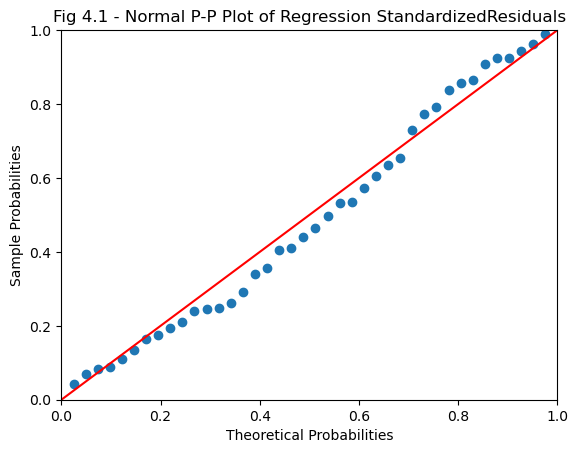

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
mba_salary_resid = scaler.fit_transform(mba_salary_lm.resid.values.reshape(-1,1))
probplot = sm.ProbPlot(mba_salary_resid.flatten())
plt.figure( figsize = (8, 6))
probplot.ppplot( line='45')
plt.title( 'Fig 4.1 - Normal P-P Plot of Regression StandardizedResiduals' )
plt.show()
